## Imports

In [1]:
import os
import math
import pandas as pd
import numpy as np
import json
from columns import *
from dotenv import find_dotenv,load_dotenv
from sql_formatter.core import format_sql
import snowflake.snowpark as snowpark
from snowflake.snowpark.types import DecimalType
from snowflake.snowpark.functions import col,sum,avg,date_sub,date_add,daydiff,array_construct,dayofweek,dayofmonth,dayofyear,when,lit,udtf,table_function
import snowflake.snowpark.functions as F
from snowflake.snowpark.types import StringType,StructField,IntegerType,FloatType,StringType,DateType,StructType,PandasDataFrameType,BooleanType
import snowflake.snowpark.types as T
from snowflake.snowpark import Session
from get_data.aggregations.aggregation import AGGREGATION_MAPPINGS
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

import datetime
import logging

import warnings
warnings.filterwarnings("ignore")

load_dotenv(find_dotenv("/Users/vivekmenon/Library/CloudStorage/OneDrive-BlueYonder/Clem/CrystallBall/.env"))

True

In [2]:
def infer_dtypes(array):
    if pd.api.types.is_datetime64_any_dtype(array):
        return DateType()
    if pd.api.types.is_int64_dtype(array):
        return IntegerType()
    if pd.api.types.is_integer_dtype(array):
        return IntegerType()
    if pd.api.types.is_categorical_dtype(array):
        return StringType()
    if pd.api.types.is_float_dtype(array):
        return FloatType()
    if pd.api.types.is_bool_dtype(array):
        return BooleanType()
    if pd.api.types.is_object_dtype(array):
        return StringType()
    return None

def get_input_schema(dataframe:pd.DataFrame)->list:
    input_schema=[]
    for col in dataframe.columns:
        input_schema.append(infer_dtypes(dataframe[col]))
    return input_schema

## Create Session

In [3]:
lde_db = "PRD_PLAN_LCS_DB"
schema = 'ADMIN_SCRIPTS'

credentials={
        "user"          : "PRD_PLAN_LCS_CUSTOMER_E8F30DDB-BCBA-4CA5-B739-D3DF665A1F0D_USER",
        "account"       : "by-euw_prd",
        "warehouse"     : "PRD_PLAN_LCS_ADHOC_ALL_WH",
        "role"          : "PRD_PLAN_LCS_ENGINEER_FR"
        }
db_session=Session.builder.configs(credentials).create()


lde_db_schema=f'{lde_db}.{schema}'

In [4]:
#%%
import os
import pandas as pd
import numpy as np
import json
from get_data.columns import *
from dotenv import find_dotenv,load_dotenv
import snowflake.snowpark as snowpark
from snowflake.snowpark.types import DecimalType
from snowflake.snowpark.functions import col,sum,avg,date_sub,date_add,daydiff,array_construct,dayofweek,dayofmonth,dayofyear,when,lit,udtf,table_function
import snowflake.snowpark.functions as F
from snowflake.snowpark.types import StringType,StructField,IntegerType,FloatType,StringType,DateType,StructType,PandasDataFrameType,BooleanType
import snowflake.snowpark.types as T
from snowflake.snowpark import Session

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from get_data.get_credentials import SnowflakeConfig
from get_data.data_retrival_and_transformation import *
from get_data.aggregations.aggregation import *
from get_data.aggregations.aggregation_columns import *
from write_data.write_data import *

import datetime
import logging

import warnings
warnings.filterwarnings("ignore")

load_dotenv(find_dotenv("/Users/vivekmenon/Library/CloudStorage/OneDrive-BlueYonder/Clem/CrystallBall/MOR.env"))
# %%
def activate_creds():
    config_data = {
    "READ_DB": os.getenv("READ_DB"),
    # "READ_ROLE": os.getenv("READ_ROLE"),
    "READ_SCHEMA": os.getenv("READ_SCHEMA"),
    "WRITE_DB": os.getenv("WRITE_DB"),
    "WRITE_SCHEMA": os.getenv("WRITE_SCHEMA"),
    "ACCOUNT": os.getenv("ACCOUNT"),
    "READ_WH": os.getenv("READ_WH"),
    "WRITE_WH": os.getenv("WRITE_WH"),
    # "WRITE_ROLE": os.getenv("WRITE_ROLE"),
    "USER_NAME": os.getenv("USER_NAME"),
    "PASSWORD": os.getenv("PASSWORD"),
    }
    return SnowflakeConfig(**config_data)

def get_all_data(db_session,scope_dict,config):
    scp_data = fetch_scp_data(db_session,
                   config.read_db,
                   config.read_schema,
                   scope_dict)
    
    scp_data.show()
    
    location_data = fetch_location_data(db_session,
                   config.read_db,
                   config.read_schema,
                   scope_dict)
    
    location_data.show()

    product_data = fetch_product_data(db_session,
                   config.read_db,
                   config.read_schema,
                   scope_dict)
    
    product_data.show()

    prediction_data = fetch_prediction_data(db_session,
                   config.read_db,
                   config.read_schema,
                   scope_dict)
    
    prediction_data.show()

    event_data = fetch_event_data(db_session,
                   config.read_db,
                   config.read_schema,
                   scope_dict,
                   location_data)
    
    event_data.show()

    return scp_data,location_data,product_data,prediction_data,event_data

def _get_event_selection(db_session,config):
 
    
    event_data = fetch_event_data_selection(db_session,
                   config.read_db,
                   config.read_schema,
                   )
    
    return event_data.select(
        col(E_BY_NAME),
        col(E_DATE_FROM),
        col(E_DATE_UPTO),
        col(E_SOURCE)
    ).distinct().toPandas()

def attach_pl_to_data(scp_data,prediction_data,product_data,location_data):
    training_data=attach_product_and_location_data(
        scp_data,
        product_data=product_data,
        location_data=location_data
    )

    predict_data = attach_product_and_location_data(
        prediction_data,
        product_data=product_data,
        location_data=location_data
    )

    return training_data,predict_data

def get_event_data_and_write(event_data,db_session,config):
    pivoted_event = get_pivoted_events(event_data=event_data)
    pivoted_event.columns = [p.replace(" ","_").upper() for p in pivoted_event.columns]

    write_into_table_from_pandas(pivoted_event,
                                 db_session,
                                 config.write_db,
                                 config.write_schema,
                                 table_name="EVENTS_CLEM_DATA",
                                 to_overwrite=True)
    # return pivoted_event
    
def join_events_based_on_agg(db_session,config,event_data,training_data,predict_data,scope_dict):
    validate_input(agg_criteria=scope_dict["AGGREGATION"])

    data = get_aggregated_data(AGGREGATION_MAPPINGS[scope_dict["AGGREGATION"]],training_data,
                               agg_col=AGG_COL_SALES)
    
    predict_data = get_aggregated_data(AGGREGATION_MAPPINGS[scope_dict["AGGREGATION"]],predict_data,
                               agg_col=AGG_COL_PRED)
    print(AGGREGATION_MAPPINGS[scope_dict["AGGREGATION"]])
    if "l_external_code" in AGGREGATION_MAPPINGS[scope_dict["AGGREGATION"]]:
        data.show()
        training_data_w_events=data.join(
            event_data,
            how="left",
            on=(
                (data["L_EXTERNAL_CODE"]==event_data["E_L_EXTERNAL_CODE"])
            &   (data["C_DATE"]==event_data["E_C_DATE"])
            )
        )
        predict_data_w_events=predict_data.join(
        event_data,
        how="left",
        on=(
            (predict_data["L_EXTERNAL_CODE"]==event_data["E_L_EXTERNAL_CODE"])
        &   (predict_data["C_DATE"]==event_data["E_C_DATE"])
        )
        )
        # drop_table(db_session,config.write_db,config.write_schema,"EVENTS_CLEM_AGG_DATA")
        # write_tables_snowpark(event_data,db=config.write_db,schema=config.write_schema,table_name="EVENTS_CLEM_AGG_DATA",write_mode="overwrite")
    else:
        aggregated_events_data = get_aggregated_data(
            group_by_cols_cols=[
                "E_C_DATE"
            ]+[n.replace(" ","_").upper() for n in scope_dict["EVENT_NAME"]],
            data=event_data,
            agg_col=AGG_COL_EVENT
        )
        aggregated_events_data.show()
        training_data_w_events=data.join(
            aggregated_events_data,
            how="left",
            on=(
                (data["C_DATE"]==aggregated_events_data["E_C_DATE"])
            )
        )
        predict_data_w_events=predict_data.join(
        aggregated_events_data,
        how="left",
        on=(
            (predict_data["C_DATE"]==aggregated_events_data["E_C_DATE"])
        )
        )
        # drop_table(db_session,config.write_db,config.write_schema,"EVENTS_CLEM_AGG_DATA")
        # write_tables_snowpark(aggregated_events_data,db=config.write_db,schema=config.write_schema,table_name="EVENTS_CLEM_AGG_DATA",write_mode="overwrite")

    return training_data_w_events,predict_data_w_events

# %%
def start_data_process(scope_dict):
    """
    Main function to execute the data pipeline.
    """
    print("Starting main")
    # Step 1: Initialize Snowpark session
    config = activate_creds()
    db_session = config.create_session()
    db_session.use_role(os.getenv('WRITE_ROLE'))
    # db_session.sql(f"USE SECONDARY ROLE {os.getenv('READ_ROLE')}").collect()
    # Step 2: Fetch all required data
    print("Fetching all required data")
    scp_data,location_data,product_data,prediction_data,event_data = get_all_data(
        db_session,scope_dict,config)

    # Step 3: Attach product locations to sales and prediction data
    print("Attaching product locations to sales and prediction data")
    training_data,predict_data = attach_pl_to_data(
        scp_data,prediction_data,product_data,location_data)

    # Step 4: Write event data to a table
    print("Writing event data to a table")
    
    # db_session.use_role()
    # db_session.use_database(config.write_db)
    # drop_table(db_session,config.write_db,config.write_schema,"EVENTS_CLEM_DATA")
    get_event_data_and_write(event_data,db_session,config)
    event_data = db_session.table(
        f'{config.write_db}.{config.write_schema}.EVENTS_CLEM_DATA')
    print(event_data.columns)
    # training_data.write.mode("overwrite").save_as_table(f"{os.getenv('WRITE_DB')}.{os.getenv('WRITE_SCHEMA')}.CLEM_TRAINING_DATA_1",block=True)


    # Step 5: Join event data with training and prediction data
    print("Joining event data with training and prediction data")
    training_data_w_events,predict_data_w_events=join_events_based_on_agg(
        db_session,config,event_data,training_data,predict_data,scope_dict)
    training_data_w_events.show()
    # Step 6: Write training and prediction data to a table
    print("Writing training and prediction data to a table")

    # drop_table(db_session,config.write_db,config.write_schema,"CLEM_TRAINING_DATA")
    # db_session.use_role(os.getenv("WRITE_ROLE"))
    # db_session.use_database(config.write_db)
    # training_data_w_events.write.mode("overwrite").save_as_table("CLEM_TRAINING_DATA",block=True)

    write_tables_snowpark(
        training_data_w_events,config.write_db,config.write_schema,
        table_name="CLEM_TRAINING_DATA_ALL",write_mode="overwrite")
    
    # drop_table(db_session,config.write_db,config.write_schema,"CLEM_PREDICTION_DATA")
    write_tables_snowpark(
        predict_data_w_events,config.write_db,config.write_schema,
        table_name="CLEM_PREDICTION_DATA_ALL",write_mode="overwrite")
    
def get_product_data():
    config = activate_creds()
    db_session = config.create_session()
    return fetch_product_data_wo_scope(db_session,config.read_db,config.read_schema).toPandas()

def get_location_data():
    config = activate_creds()
    db_session = config.create_session()
    return fetch_location_data_wo_scope(db_session,config.read_db,config.read_schema)\
        .select(col("L_EXTERNAL_CODE"),col(L_NAME)).distinct().toPandas()

def get_event_data_for_selection():
    config = activate_creds()
    db_session = config.create_session()

    return _get_event_selection(db_session,config)

In [5]:
scope_dict = {
  "EVENT_SOURCE": [
    "PREDICTHQ"
  ],
  "L_EXTERNAL_CODE": list(),
  "l_external_code": [
    "259|RUBERY BRISTOL RD SOUTH"
  ],
  "DATE_FROM": datetime.date(2024, 11, 1),
  "product_element": [
    "223-81-339|Scotch Malt"
  ],
  "EVENT_NAME": [
    "Thanksgiving Day"
  ],
  "AGGREGATION": "pg3_location",
  "SUBMIT": True,
  "DATE_UPTO": datetime.date(2024, 11, 30),
  "HIGH_LEVEL": "PG_EXTERNAL_CODE_3",
  "PRODUCT_ELEMENTS": ["16_4_"]
}

In [6]:
start_data_process(scope_dict=scope_dict)

INFO:snowflake.connector.connection:Snowflake Connector for Python Version: 3.10.0, Python Version: 3.9.6, Platform: macOS-14.7.1-arm64-arm-64bit
INFO:snowflake.connector.connection:This connection is in OCSP Fail Open Mode. TLS Certificates would be checked for validity and revocation status. Any other Certificate Revocation related exceptions or OCSP Responder failures would be disregarded in favor of connectivity.


Starting main


INFO:snowflake.snowpark.session:Snowpark Session information: 
"version" : 1.24.0,
"python.version" : 3.9.6,
"python.connector.version" : 3.10.0,
"python.connector.session.id" : 53613307582654659,
"os.name" : Darwin

INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:get_data.data_retrival_and_transformation:Fetching data from source_clp_loc with filters: Column["C_DATE" >= LITERAL AND "C_DATE" <= LITERAL AND "VALID_SALE" = LITERAL AND "_ASSIGNMENT_SALE" = LITERAL]


Fetching all required data


INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 10
INFO:get_data.data_retrival_and_transformation:Fetching data from locations with filters: Column["C_DATE" >= LITERAL AND "C_DATE" <= LITERAL AND "L_IS_OPEN" = LITERAL]


...

INFO:snowflake.connector.cursor:Number of results in first chunk: 10
INFO:snowflake.connector.cursor:Number of results in first chunk: 0


-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"C_DATE"    |"PG_EXTERNAL_CODE_3"  |"L_EXTERNAL_CODE"  |"SALES"       |"PROMOTION_COUNT"  |"LIST_PRICE"  |"CURRENT_PRICE"  |"COUNT"  |"E_C_DATE"  |"E_L_EXTERNAL_CODE"  |"THANKSGIVING_DAY"  |
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|2023-03-02  |16_4_                 |358                |14.00000000   |0.000000           |3.6525000000  |3.6525000000     |8        |NULL        |NULL                 |NULL                |
|2024-09-14  |16_4_                 |348                |12.00000000   |0.000000           |2.6900000000  |2.6900000000     |4        |NULL        |NULL                 |NULL                |
|2023-02-10  |16_4_                 |808

INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 10
INFO:snowflake.connector.cursor:Number of results in first chunk: 0


--------------------------------------------------------------------------------------------------------------------------------------
|"C_DATE"    |"PG_EXTERNAL_CODE_3"  |"L_EXTERNAL_CODE"  |"PRED_MEAN"         |"E_C_DATE"  |"E_L_EXTERNAL_CODE"  |"THANKSGIVING_DAY"  |
--------------------------------------------------------------------------------------------------------------------------------------
|2024-11-14  |16_4_                 |126                |43.22762509807944   |2024-11-14  |126                  |-14                 |
|2024-11-14  |16_4_                 |139                |30.01182598248124   |2024-11-14  |139                  |-14                 |
|2024-11-14  |16_4_                 |145                |21.371380425989628  |2024-11-14  |145                  |-14                 |
|2024-11-14  |16_4_                 |147                |31.212248474359512  |2024-11-14  |147                  |-14                 |
|2024-11-14  |16_4_                 |160               

INFO:snowflake.connector.cursor:Number of results in first chunk: 1


In [7]:
import os
import math
import pandas as pd
import numpy as np
import json
from columns import *
from dotenv import find_dotenv,load_dotenv
from sql_formatter.core import format_sql
import snowflake.snowpark as snowpark
from snowflake.snowpark.types import DecimalType
from snowflake.snowpark.functions import col,sum,avg,date_sub,date_add,daydiff,array_construct,dayofweek,dayofmonth,dayofyear,when,lit,udtf,table_function
import snowflake.snowpark.functions as F
from snowflake.snowpark.types import StringType,StructField,IntegerType,FloatType,StringType,DateType,StructType,PandasDataFrameType,BooleanType
import snowflake.snowpark.types as T
from snowflake.snowpark import Session
from get_data.aggregations.aggregation import AGGREGATION_MAPPINGS
from get_data.get_credentials import SnowflakeConfig

from init_udtf_model import init_udtf_model

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from snowflake.snowpark.functions import udf, col
from snowflake.snowpark.types import StructType, StructField, StringType, VariantType, FloatType
import pandas as pd
import snowflake.snowpark.types as T
import snowflake.snowpark.functions as F
from sklearn.ensemble import RandomForestRegressor

from write_data.write_data import *

from functools import partial

import datetime
import logging

import warnings
warnings.filterwarnings("ignore")

load_dotenv(find_dotenv("/Users/vivekmenon/Library/CloudStorage/OneDrive-BlueYonder/Clem/CrystallBall/MOR.env"))


class PromoFeatureExtraction():
    def __init__(self) -> None:
        self.rows = []
    def process(self, data,needed_cols,feature_columns,event_columns,date_from,date_upto,name):
        self.needed_cols = needed_cols+feature_columns+event_columns
        self.residual_cols = event_columns
        self.feature_columns = feature_columns
        self.event_columns = event_columns
        self.date_from = date_from
        self.date_upto = date_upto
        self.name = name
        self.rows.append(data)
    def end_partition(self):
        self.df = pd.DataFrame(self.rows)
        df = round(self.df[self.needed_cols],4)
        for col in self.residual_cols:
            df[col] = df[col].fillna(-15)
        df["C_DATE"] = pd.to_datetime(df["C_DATE"]).dt.date
        df.loc[(df["C_DATE"] >= self.date_from) & (df["C_DATE"] <= self.date_upto),"TYPE"]=0
        df.loc[(df["C_DATE"] < self.date_from),"TYPE"]=1

        X = df[df["TYPE"]==1][self.feature_columns]
        Y = df[df["TYPE"]==1]["SALES"]

        model = self.model_init(X,Y)

        x = df[df["TYPE"]==0][self.feature_columns]
        y = df[df["TYPE"]==0]["SALES"]

        pred = model.predict(x)
        in_sample = model.predict(X)

        df.loc[df["TYPE"]==0,f"{self.name}_PRED"] = pred
        df.loc[df["TYPE"]==1,f"{self.name}_PRED"] = in_sample

        df["RESIDUALS"]= df["SALES"]-df[f"{self.name}_PRED"]
        X = df[df["TYPE"]==1][self.residual_cols]
        Y = df[df["TYPE"]==1]["RESIDUALS"]

        x = df[df["TYPE"]==0][self.residual_cols]
        y = df[df["TYPE"]==0]["RESIDUALS"]


        r_model = self.model_init(X,Y)
        
        in_sample_r = r_model.predict(X)
        pred = r_model.predict(x)

        df.loc[df["TYPE"]==1,f"{self.name}_RESD"] = in_sample_r
        df.loc[df["TYPE"]==0,f"{self.name}_RESD"] = pred

        df_dict = pd.DataFrame()

        df_dict["ROW"] = df.to_dict(orient="records")

        for idx,data in df_dict.iterrows():
            yield(data.ROW,)
        # yield from df_dict.itertuples(index=False)
    def model_init(self,X,Y):
        model = RandomForestRegressor(min_samples_split=3,criterion="squared_error",n_estimators=500)
        model.fit(X,Y)
        return model    

def activate_creds():
    config_data = {
    "READ_DB": os.getenv("READ_DB"),
    "READ_SCHEMA": os.getenv("READ_SCHEMA"),
    "WRITE_DB": os.getenv("WRITE_DB"),
    "WRITE_SCHEMA": os.getenv("WRITE_SCHEMA"),
    "ACCOUNT": os.getenv("ACCOUNT"),
    "READ_WH": os.getenv("READ_WH"),
    "WRITE_WH": os.getenv("WRITE_WH"),
    "USER_NAME": os.getenv("USER_NAME"),
    "PASSWORD": os.getenv("PASSWORD"),
    }
    return SnowflakeConfig(**config_data)



def create_partition_columns(agg_col:list):
    agg_col.remove("c_date")

    snowpark_col = [F.col(col) for col in agg_col]

    return snowpark_col

def get_training_table(db_session:Session,config:SnowflakeConfig,partition_by_cols,scope_dict):
    event_names=[n.upper() for n in scope_dict["EVENT_NAME"]]
    training_data = db_session.table(f"{config.write_db}.{config.write_schema}.CLEM_TRAINING_DATA_ALL").select(
    *partition_by_cols,
    *event_names,
    C_DATE,
    PROMOTION_COUNT,
    LIST_PRICE,
    CURRENT_PRICE,
    SALES,
    # F.sin((2*math.pi*F.dayofyear(C_DATE))/365).as_("DAYOFYEAR_SIN_WAVE"),
    # F.cos((2*math.pi*F.dayofyear(C_DATE))/365).as_("DAYOFYEAR_COS_WAVE"),
    F.sin((2*math.pi*F.dayofweek(C_DATE))/7).as_("DAYOFWEEK_SIN_WAVE"),
    F.cos((2*math.pi*F.dayofweek(C_DATE))/7).as_("DAYOFWEEK_COS_WAVE"),
    F.sin((2*math.pi*F.dayofmonth(C_DATE))/31).as_("DAYOFMONTH_SIN_WAVE"),
    F.cos((2*math.pi*F.dayofmonth(C_DATE))/31).as_("DAYOFMONTH_COS_WAVE")
    ).drop(
        "E_C_DATE",
        "E_L_EXTERNAL_CODE"
    ).na.fill({n.upper():-15 for n in scope_dict["EVENT_NAME"]}).order_by(C_DATE)

    rename_cols = {col : col.replace("'","").upper() for col in training_data.columns}

    training_data = training_data.rename(rename_cols)

    return training_data


def get_key_components(data: snowpark.DataFrame):
    """Construct a list of columns and their corresponding literal column names."""
    key_components = []
    for column in data.columns:
        key_components.append(lit(column))
        key_components.append(F.col(column))
    return key_components

def preprocessing(data: snowpark.DataFrame,key_components:list,partition_by_cols:list):
    data_table = data.with_column(
    "VARIANT_COL", F.object_construct_keep_null(*key_components)
    ).select(*partition_by_cols,F.col("VARIANT_COL")).drop("C_DATE").distinct()
    data_table.show()
    return data_table

def run_udtf_model(train_data:snowpark.DataFrame,udtf_model:snowpark.udtf
                   ,partition_by_cols:list,scope_dict:dict,org_cols:list,feature_cols:list,resid_cols:list,
                   model_type:str):
    return train_data.select(*partition_by_cols,
    (
        udtf_model(
            F.parse_json(F.col("VARIANT_COL").cast(T.VariantType())),# data
            F.lit([n.upper() for n in org_cols]),# needed_cols
            F.lit([n.upper() for n in feature_cols]),#feature_cols
            F.lit([n.upper() for n in resid_cols]),#event_cols
            F.lit(scope_dict["DATE_FROM"]),#date_from
            F.lit(scope_dict["DATE_UPTO"]),# date_upto
            F.lit(model_type.upper())#model_type
            ).over(
    partition_by=partition_by_cols
    )
            )
        )

def get_types(scope_dict):
    TYPES = {
        "PG_EXTERNAL_CODE_1":T.StringType(),
        "PG_EXTERNAL_CODE_2":T.StringType(),
        "PG_EXTERNAL_CODE_3":T.StringType(),
        "PG_EXTERNAL_CODE_4":T.StringType(),
        "PG_EXTERNAL_CODE_5":T.StringType(),
        "PG_EXTERNAL_CODE_6":T.StringType(),
        "PG_EXTERNAL_CODE_7":T.StringType(),
        "PG_EXTERNAL_CODE_8":T.StringType(),
        "SALES":T.IntegerType(),
        "PRED_MEAN":T.FloatType(),
        "TYPE":T.IntegerType(),
        "C_DATE":T.DateType(),
        "L_EXTERNAL_CODE":T.StringType(),
        "COUNT_OF_LOCATIONS":T.IntegerType(),
        "CURRENT_PRICE":T.FloatType(),
        "LIST_PRICE":T.FloatType(),
        "PROMO_PRED":T.FloatType(),
        "PROMO_RESD":T.FloatType(),
        "PROMOTION_COUNT":T.IntegerType(),
        "RESIDUALS":T.FloatType(),
        "DAYOFMONTH_COS_WAVE":FloatType(),
        "DAYOFMONTH_SIN_WAVE":FloatType(),
        "DAYOFWEEK_COS_WAVE":FloatType(),
        "DAYOFWEEK_SIN_WAVE":FloatType(),
        "DAYOFYEAR_COS_WAVE":FloatType(),
        "DAYOFYEAR_SIN_WAVE":FloatType(),
        "EVENT_PRED":FloatType(),
        "EVENT_RESD":FloatType(),
        "SEASON_PRED":FloatType(),
        "SEASON_RESD":FloatType(),
        "PRICE_PRED":FloatType(),
        "PRICE_RESD":FloatType(),
        "TREND_MEAN":FloatType(),
        "YHAT":FloatType(),
        "SEASON_MEAN":FloatType(),
        "TREND_MEAN":FloatType(),
    }

    TYPES.update({
        f'{k.upper()}':T.IntegerType() for k in scope_dict["EVENT_NAME"]
    })

    return TYPES

def post_processing(udtf_output:snowpark.DataFrame,scope_dict:dict):
    types = get_types(scope_dict)
    key_list = udtf_output.join_table_function("flatten",F.col("ENTIRE_ROW")).select(F.col("KEY")).distinct().toPandas()["KEY"].tolist()
    key_list = [F.col("ENTIRE_ROW").getField(key).cast(types[key]).alias(key) for key in key_list]

    return udtf_output.select(*key_list)

def run_model(scope_dict):
    config = activate_creds()
    db_session=config.create_session()
    db_session.use_role(os.getenv('WRITE_ROLE'))

    agg_parameter = scope_dict["AGGREGATION"]
    agg_cols = AGGREGATION_MAPPINGS[agg_parameter]

    partition_by_cols = create_partition_columns(agg_col=agg_cols)

    training_data = get_training_table(db_session,config,partition_by_cols,scope_dict)
    key_components = get_key_components(training_data)
    print(key_components)
    training_data.show()

    train_pre_process = preprocessing(training_data,key_components,partition_by_cols)
    train_pre_process.show()

    db_session.use_database(config.write_db)
    db_session.use_schema(config.write_schema)
    # udtf_model = init_udtf_model(db_session)


    udtf_model = table_function(f"{config.write_db}.{config.write_schema}.FeatureExtraction")
    # holt_model = table_function(f"{config.write_db}.{config.write_schema}.HoltsModel")
    linear_model_udtf = table_function(f"{config.write_db}.{config.write_schema}.LinearModel")

    print("Start")
    event_feature_cols = [f'{n.upper()}' for n in scope_dict["EVENT_NAME"]]
    event_residual_cols = ['LIST_PRICE','DAYOFWEEK_SIN_WAVE','CURRENT_PRICE','PROMOTION_COUNT','DAYOFWEEK_COS_WAVE']
    
    event_model = run_udtf_model(
        train_pre_process,
        udtf_model,
        partition_by_cols,
        scope_dict,
        training_data.columns,
        event_feature_cols,
        event_residual_cols,
        "EVENT"
    )

    promo_feature_cols = [PROMOTION_COUNT,"CURRENT_PRICE"]+event_feature_cols
    promo_residual_cols = ['DAYOFWEEK_COS_WAVE', 'LIST_PRICE', 'DAYOFWEEK_SIN_WAVE']
    
    promo_model = run_udtf_model(
        train_pre_process,
        udtf_model,
        partition_by_cols,
        scope_dict,
        training_data.columns,
        promo_feature_cols,
        promo_residual_cols,
        "PROMO"
    )

    

    season_feature_cols = ["DAYOFWEEK_SIN_WAVE","DAYOFWEEK_COS_WAVE"]+event_feature_cols
    season_residual_cols = ['CURRENT_PRICE', 'LIST_PRICE', 'PROMOTION_COUNT']
    
    season_model = run_udtf_model(
        train_pre_process,
        udtf_model,
        partition_by_cols,
        scope_dict,
        training_data.columns,
        season_feature_cols,
        season_residual_cols,
        "SEASON"
    )

    price_feature_cols = [LIST_PRICE,CURRENT_PRICE]+event_feature_cols
    price_residual_cols = ['PROMOTION_COUNT']
    
    price_model = run_udtf_model(
        train_pre_process,
        udtf_model,
        partition_by_cols,
        scope_dict,
        training_data.columns,
        price_feature_cols,
        price_residual_cols,
        "PRICE"
    )

    price_feature_cols = [LIST_PRICE,CURRENT_PRICE]+event_feature_cols
    price_residual_cols = ['PROMOTION_COUNT']
    
    price_model = run_udtf_model(
        train_pre_process,
        udtf_model,
        partition_by_cols,
        scope_dict,
        training_data.columns,
        price_feature_cols,
        price_residual_cols,
        "PRICE"
    )

    # trend_model = train_pre_process.select(
    #     *partition_by_cols,
    #     holt_model(
    #         F.parse_json(F.col("VARIANT_COL").cast(T.VariantType())),
    #         F.lit(scope_dict["DATE_FROM"]),
    #         F.lit(scope_dict["DATE_UPTO"]),
    #         ).over(partition_by=partition_by_cols)
    #         )

    promo_model,event_model,season_model,price_model = post_processing(promo_model,scope_dict),post_processing(event_model,scope_dict),post_processing(season_model,scope_dict),post_processing(price_model,scope_dict)
    print("Done")
    linear_model_feed = event_model\
    .join(promo_model, on=(*agg_cols,C_DATE)
    ).join(season_model, on=(*agg_cols,C_DATE)
    ).join(price_model, on=(*agg_cols,C_DATE)
    # ).join(trend_model, on=(*agg_cols,C_DATE)
    ).select(
        *agg_cols,
        C_DATE,
        event_model["SALES"].as_("SALES"),
        event_model["EVENT_RESD"],
        event_model["EVENT_PRED"],
        promo_model["PROMO_RESD"],
        promo_model["PROMO_PRED"],
        season_model["SEASON_RESD"],
        season_model["SEASON_PRED"],
        price_model["PRICE_RESD"],
        price_model["PRICE_PRED"],
        # trend_model["TREND_MEAN"]
    )
    key_components_2 = get_key_components(linear_model_feed)
    
    linear_model_feed = linear_model_feed.with_column("VARIANT_COL",F.object_construct_keep_null(*key_components_2)).select(*partition_by_cols,"VARIANT_COL").distinct()
    linear_result = linear_model_feed.select(*partition_by_cols,
                   linear_model_udtf(
                       F.parse_json(F.col("VARIANT_COL").cast(T.VariantType())),
                       lit(scope_dict["DATE_FROM"]),
                       lit(scope_dict["DATE_UPTO"])
                   ).over(
                    partition_by=partition_by_cols
                   ))
    
    final_result = post_processing(linear_result,scope_dict)
    write_tables_snowpark(final_result,config.write_db,config.write_schema,"CLEM_PREDICTION_FULLSCOPE_50","append")

    return linear_result


In [8]:
scope_dict = {
  "EVENT_SOURCE": [
    "PREDICTHQ"
  ],
  "L_EXTERNAL_CODE": list(),
  "l_external_code": [
    "259|RUBERY BRISTOL RD SOUTH"
  ],
  "DATE_FROM": datetime.date(2024, 11, 1),
  "product_element": [
    "223-81-339|Scotch Malt"
  ],
  "EVENT_NAME": [
    "Thanksgiving_Day".upper()
  ],
  "AGGREGATION": "pg3_location",
  "SUBMIT": True,
  "DATE_UPTO": datetime.date(2024, 11, 30),
  "HIGH_LEVEL": "PG_EXTERNAL_CODE_3",
  "PRODUCT_ELEMENTS": ["16_80_"]
}

In [9]:
meta=run_model(scope_dict)

INFO:snowflake.connector.connection:Snowflake Connector for Python Version: 3.10.0, Python Version: 3.9.6, Platform: macOS-14.7.1-arm64-arm-64bit
INFO:snowflake.connector.connection:This connection is in OCSP Fail Open Mode. TLS Certificates would be checked for validity and revocation status. Any other Certificate Revocation related exceptions or OCSP Responder failures would be disregarded in favor of connectivity.
INFO:snowflake.snowpark.session:Snowpark Session information: 
"version" : 1.24.0,
"python.version" : 3.9.6,
"python.connector.version" : 3.10.0,
"python.connector.session.id" : 53613307582669663,
"os.name" : Darwin

INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connect

[Column(LITERAL), Column("PG_EXTERNAL_CODE_3"), Column(LITERAL), Column("L_EXTERNAL_CODE"), Column(LITERAL), Column("THANKSGIVING_DAY"), Column(LITERAL), Column("C_DATE"), Column(LITERAL), Column("PROMOTION_COUNT"), Column(LITERAL), Column("LIST_PRICE"), Column(LITERAL), Column("CURRENT_PRICE"), Column(LITERAL), Column("SALES"), Column(LITERAL), Column("DAYOFWEEK_SIN_WAVE"), Column(LITERAL), Column("DAYOFWEEK_COS_WAVE"), Column(LITERAL), Column("DAYOFMONTH_SIN_WAVE"), Column(LITERAL), Column("DAYOFMONTH_COS_WAVE")]


INFO:snowflake.connector.cursor:Number of results in first chunk: 10
INFO:snowflake.connector.cursor:Number of results in first chunk: 0


-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"PG_EXTERNAL_CODE_3"  |"L_EXTERNAL_CODE"  |"THANKSGIVING_DAY"  |"C_DATE"    |"PROMOTION_COUNT"  |"LIST_PRICE"  |"CURRENT_PRICE"  |"SALES"      |"DAYOFWEEK_SIN_WAVE"  |"DAYOFWEEK_COS_WAVE"  |"DAYOFMONTH_SIN_WAVE"  |"DAYOFMONTH_COS_WAVE"  |
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|16_4_                 |452                |-15                 |2023-02-06  |0.615385           |4.5592307692  |3.9469230769     |29.00000000  |0.7818314824680297    |0.6234898018587337    |0.9377521321470805     |0.34730525284482006    |
|16_4_                 |548             

INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 10


...

INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 16
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 16
INFO:snowflake.connector.cursor:Number of resu

Done


INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of result

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"PRICE_PRED"       |"PRICE_RESD"         |"EVENT_RESD"        |"PROMO_PRED"       |"EVENT_PRED"       |"L_EXTERNAL_CODE"  |"SALES"  |"SEASON_PRED"      |"PG_EXTERNAL_CODE_3"  |"TYPE"  |"YHAT"              |"PROMO_RESD"        |"C_DATE"    |"SEASON_RESD"         |
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|33.78993449871979  |-1.455890609275909   |7.193038289298004   |32.17100700688201  |39.45701870925895  |244                |46       |53.28827399342278  |16_4_                 |1       |46.81455209157217  

INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:snowflake.connector.cursor:Number of results in first chunk: 0


In [5]:
db_session.use_database(os.getenv("WRITE_DB"))
db_session.use_schema(os.getenv("WRITE_SCHEMA"))
vivek = db_session.table(f"CLEM_PREDICTION_FULLSCOPE_50")

INFO:snowflake.connector.cursor:Number of results in first chunk: 1
INFO:snowflake.connector.cursor:Number of results in first chunk: 1


In [6]:
# db_session.use_database(lde_db)
# db_session.use_schema(schema)
# vivek = db_session.table(f"{lde_db}.{schema}.CLEM_PREDICTION_FULLSCOPE_50")
# # vivek = db_session.table(f"{lde_db}.{schema}.CLEM_PREDICTION_DATA_ALL")
# # # vivek.write.mode("append").save_as_table("CLEM_PREDICTION_NEEDED_SCOPE")
# # # print("Vivek's is Done")
# # vivek = db_session.table(f"{lde_db}.{schema}.CLEM_PREDICTION_FULLSCOPE_AK")
# # # aditya.write.mode("append").save_as_table("CLEM_PREDICTION_NEEDED_SCOPE")
# # # print("Kaza's is Done")
# # vivek = db_session.table(f"{lde_db}.{schema}.CLEM_PREDICTION_FULLSCOPE_AB1")
# # # abi.write.mode("append").save_as_table("CLEM_PREDICTION_NEEDED_SCOPE")
# # # print("Abhishek's is Done")
# # # d = db_session.table(f"{lde_db}.{schema}.CLEM_PREDICTION_NEEDED_SCOPE")
pred = db_session.table(f"{os.getenv('WRITE_DB')}.{os.getenv('WRITE_SCHEMA')}.CLEM_PREDICTION_DATA_AB")

In [7]:
_1 = pred.join(vivek, on=("C_DATE","PG_EXTERNAL_CODE_3","L_EXTERNAL_CODE"))
cols = _1.columns

_3 = _1.select(*cols,
          F.when(
              ((_1["PRED_MEAN"]-_1["YHAT"])/_1["PRED_MEAN"])>0.5,
              1
          ).when(
              ((_1["PRED_MEAN"]-_1["YHAT"])/_1["PRED_MEAN"])<-0.5,
              1
          ).otherwise(0).alias("ANON"))
_3.show()

INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 10


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"C_DATE"    |"PG_EXTERNAL_CODE_3"  |"L_EXTERNAL_CODE"  |"PRED_MEAN"         |"E_C_DATE"  |"E_L_EXTERNAL_CODE"  |"THANKSGIVING_DAY"  |"PRICE_PRED"       |"PRICE_RESD"         |"EVENT_RESD"        |"PROMO_PRED"       |"EVENT_PRED"       |"SALES"  |"SEASON_PRED"      |"TYPE"  |"YHAT"              |"PROMO_RESD"         |"SEASON_RESD"       |"ANON"  |
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [8]:
_3.select("PG_EXTERNAL_CODE_3").distinct().show()

INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 2


------------------------
|"PG_EXTERNAL_CODE_3"  |
------------------------
|16_80_                |
|16_20_A               |
------------------------



In [26]:
df1 = _3[_3["PG_EXTERNAL_CODE_3"]=="16_20_A"].group_by("C_DATE").agg(F.sum("YHAT"),F.sum("SALES"),F.sum("PRED_MEAN"),F.sum("EVENT_PRED"),F.sum("SEASON_PRED"),F.sum("PROMO_PRED")).toPandas()



INFO:snowflake.connector.cursor:Number of results in first chunk: 30


<Axes: xlabel='C_DATE'>

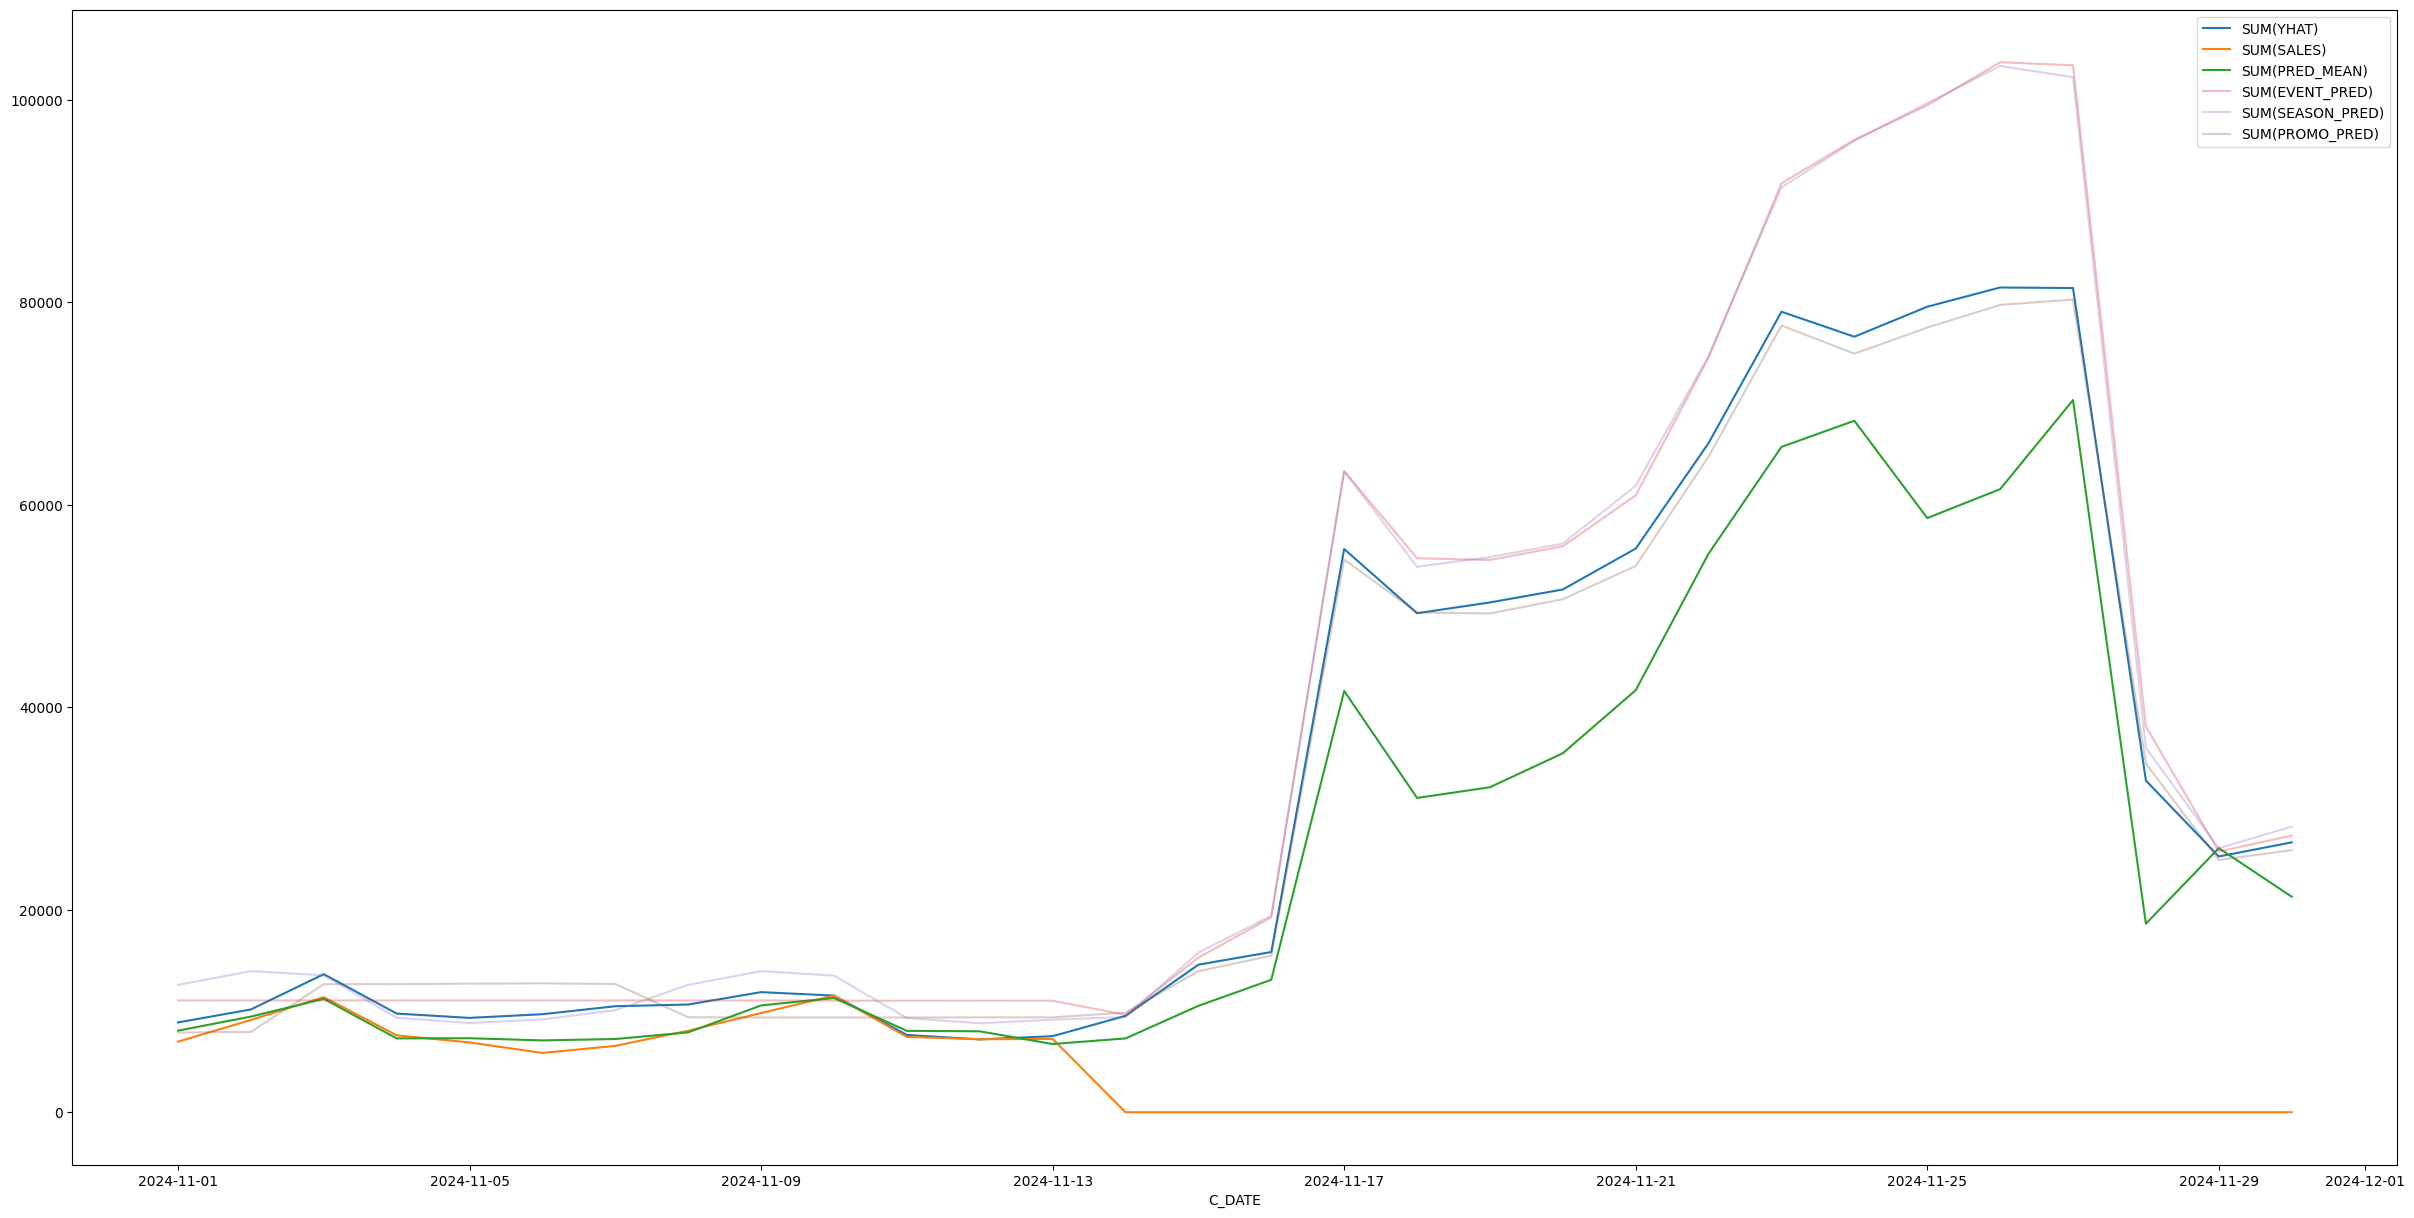

In [27]:
ax = df1.set_index("C_DATE")[["SUM(YHAT)","SUM(SALES)","SUM(PRED_MEAN)"]].plot(figsize=(30,15))
df1.set_index("C_DATE")[["SUM(EVENT_PRED)","SUM(SEASON_PRED)","SUM(PROMO_PRED)"]].plot(ax=ax,alpha=0.3)

In [16]:
meta.show()

INFO:snowflake.connector.cursor:Number of results in first chunk: 10


----------------------------------------------------------------------------------------------------------------------------------
|"PG_EXTERNAL_CODE_3"  |"L_EXTERNAL_CODE"  |"ENTIRE_ROW"                              |"META"                                    |
----------------------------------------------------------------------------------------------------------------------------------
|16_4_                 |244                |{                                         |{                                         |
|                      |                   |  "C_DATE": "2024-10-31",                 |  "Non-Residual-model": {                 |
|                      |                   |  "EVENT_PRED": 3.946377971721859e+01,    |    "-0.9758706069130892": "EVENT_PRED",  |
|                      |                   |  "EVENT_RESD": -9.923243209282152e+00,   |    "0.4624280333896831": "PRICE_PRED",   |
|                      |                   |  "L_EXTERNAL_CODE": "244",            

In [11]:
training_data = db_session.table(f"{os.getenv('WRITE_DB')}.{os.getenv('WRITE_SCHEMA')}.CLEM_TRAINING_DATA_AB")
training_data.show()

INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 10


----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"C_DATE"    |"PG_EXTERNAL_CODE_3"  |"L_EXTERNAL_CODE"  |"SALES"      |"PROMOTION_COUNT"  |"LIST_PRICE"  |"CURRENT_PRICE"  |"COUNT"  |"E_C_DATE"  |"E_L_EXTERNAL_CODE"  |"THANKSGIVING_DAY"  |
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|2022-11-10  |16_20_A               |117                |19.00000000  |0.250000           |3.4150000000  |3.3900000000     |4        |2022-11-10  |117                  |-14                 |
|2022-11-10  |16_80_                |117                |0E-8         |0.000000           |3.9900000000  |3.9900000000     |1        |2022-11-10  |117                  |-14                 |
|2022-11-10  |16_80_                |145     

In [12]:
training_data_skus = training_data.select("PG_EXTERNAL_CODE_3","L_EXTERNAL_CODE").distinct().toPandas()
training_data_skus.head()

INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 733


,PG_EXTERNAL_CODE_3,L_EXTERNAL_CODE
0,16_20_A,160
1,16_20_A,272
2,16_80_,814
3,16_20_A,296
4,16_20_A,566


In [13]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
with PdfPages("wake_fern_plots_sample.pdf") as pdf:
    for n in training_data_skus.head(20).iterrows():
        sample = training_data[(training_data["PG_EXTERNAL_CODE_3"]==n[1]["PG_EXTERNAL_CODE_3"])&(training_data["L_EXTERNAL_CODE"]==n[1]["L_EXTERNAL_CODE"])].order_by("C_DATE").toPandas()
        sample_pred = _3[(_3["PG_EXTERNAL_CODE_3"]==n[1]["PG_EXTERNAL_CODE_3"])&(_3["L_EXTERNAL_CODE"]==n[1]["L_EXTERNAL_CODE"])].order_by("C_DATE").toPandas()
        sample["C_DATE"] = pd.to_datetime(sample["C_DATE"])
        sample["YEAR"] = sample["C_DATE"].dt.year

        sample_pred["C_DATE"] = pd.to_datetime(sample_pred["C_DATE"])
        sample_pred["YEAR"] = sample_pred["C_DATE"].dt.year

        ly_sales = sample[(sample["YEAR"]==2023)&(~sample["THANKSGIVING_DAY"].isna())]
        fig,ax = plt.subplots(2,1,figsize=(30,15))
        ax[0].grid(True)
        sample_pred.set_index("C_DATE")[["PRED_MEAN","SALES","YHAT"]].plot(ax=ax[0],title=f"{n[1]['PG_EXTERNAL_CODE_3']}|{n[1]['L_EXTERNAL_CODE']}")
        ax[1].grid(True)
        ly_sales.set_index("THANKSGIVING_DAY")["SALES"].plot(ax=ax[1],alpha=0.3,)
        sample_pred.set_index("THANKSGIVING_DAY")[["YHAT"]].plot(ax=ax[1])
        pdf.savefig(fig)
        plt.close()


INFO:snowflake.connector.cursor:Number of results in first chunk: 757
INFO:snowflake.connector.cursor:Number of results in first chunk: 30
INFO:snowflake.connector.cursor:Number of results in first chunk: 756
INFO:snowflake.connector.cursor:Number of results in first chunk: 30
INFO:snowflake.connector.cursor:Number of results in first chunk: 754
INFO:snowflake.connector.cursor:Number of results in first chunk: 30
INFO:snowflake.connector.cursor:Number of results in first chunk: 756
INFO:snowflake.connector.cursor:Number of results in first chunk: 30
INFO:snowflake.connector.cursor:Number of results in first chunk: 757
INFO:snowflake.connector.cursor:Number of results in first chunk: 30
INFO:snowflake.connector.cursor:Number of results in first chunk: 37
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 758
INFO:snowflake.connector.cursor:Number of results in first chunk: 30
INFO:snowflake.connector.curs

In [49]:
n

(0,
 PG_EXTERNAL_CODE_3    16_20_A
 L_EXTERNAL_CODE           160
 Name: 0, dtype: object)

In [40]:
sample["C_DATE"] = pd.to_datetime(sample["C_DATE"])
sample["YEAR"] = sample["C_DATE"].dt.year

sample_pred["C_DATE"] = pd.to_datetime(sample_pred["C_DATE"])
sample_pred["YEAR"] = sample_pred["C_DATE"].dt.year


In [41]:
ly_sales = sample[(sample["YEAR"]==2023)&(~sample["THANKSGIVING_DAY"].isna())]

<Axes: xlabel='THANKSGIVING_DAY'>

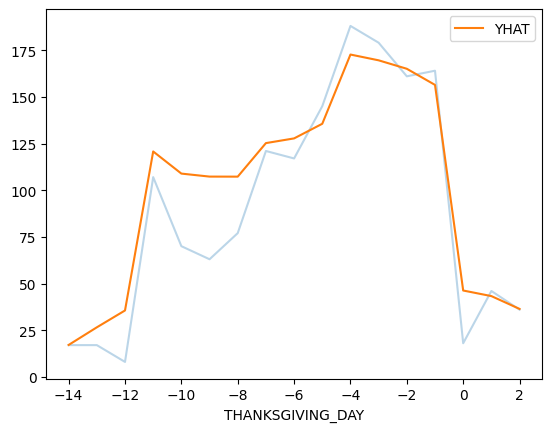

In [45]:
ax = ly_sales.set_index("THANKSGIVING_DAY")["SALES"].plot(alpha=0.3)
sample_pred.set_index("THANKSGIVING_DAY")[["YHAT"]].plot(ax=ax)

In [116]:
train = db_session.table(f"{lde_db}.{schema}.CLEM_TRAINING_DATA_ALL")
total_PLs = train.select("PG_EXTERNAL_CODE_5","L_EXTERNAL_CODE").distinct().toPandas()

INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 3269


In [117]:
len(total_PLs)

212617

In [62]:
len(vivek.select("PG_EXTERNAL_CODE_5").distinct().toPandas()["PG_EXTERNAL_CODE_5"].unique().tolist())

INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 288


288

In [63]:
len(vivek.select("L_EXTERNAL_CODE").distinct().toPandas()["L_EXTERNAL_CODE"].unique().tolist())

INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 274


274

In [149]:
d = vivek.select(*vivek.columns,vivek["PG_EXTERNAL_CODE_5"].in_(pg5).as_("PG_EXISTS"),vivek["L_EXTERNAL_CODE"].in_(loc).as_("LOC_EXISTS"))

INFO:snowflake.connector.cursor:Number of results in first chunk: 0


In [150]:
d = vivek.select(*vivek.columns,vivek["PG_EXTERNAL_CODE_5"].in_(sent_pg5s).as_("PG_EXISTS"),vivek["L_EXTERNAL_CODE"].in_(sent_loc).as_("LOC_EXISTS"))
# d.where(d["LOC_EXISTS"]==False).select("L_EXTERNAL_CODE").distinct().toPandas()["L_EXTERNAL_CODE"].nunique()

In [153]:
d = vivek.where(vivek["PG_EXTERNAL_CODE_5"].in_(pg5)&(vivek["L_EXTERNAL_CODE"].in_(loc)))

In [154]:
len(d.select("PG_EXTERNAL_CODE_5").distinct().toPandas()["PG_EXTERNAL_CODE_5"].unique().tolist())

INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 30


30

In [155]:
len(d.select("L_EXTERNAL_CODE").distinct().toPandas()["L_EXTERNAL_CODE"].unique().tolist())

INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 268


268

In [145]:
d.show()

INFO:snowflake.connector.cursor:Number of results in first chunk: 10


------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"SEASON_RESD"       |"PRICE_RESD"          |"EVENT_PRED"      |"YHAT"              |"SALES"  |"EVENT_RESD"        |"L_EXTERNAL_CODE"  |"TYPE"  |"PROMO_RESD"          |"PG_EXTERNAL_CODE_5"  |"PRICE_PRED"       |"PROMO_PRED"       |"C_DATE"    |"SEASON_PRED"      |
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|-12.58278785209465  |-0.2268240860414592   |59.0182816691956  |52.45210222454244   |61       |-2.526603339907372  |STR-033            |1       |-0.03841977945559603  |L2-012455             |45.90395823446

In [146]:
check_pg = set(d.select("PG_EXTERNAL_CODE_5").distinct().toPandas()["PG_EXTERNAL_CODE_5"].unique().tolist())

INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 485


In [156]:
_1 = pred.join(d, on=("C_DATE","PG_EXTERNAL_CODE_5","L_EXTERNAL_CODE"))
cols = _1.columns

_3 = _1.select(*cols,
          F.when(
              ((_1["PRED_MEAN"]-_1["YHAT"])/_1["PRED_MEAN"])>0.5,
              1
          ).when(
              ((_1["PRED_MEAN"]-_1["YHAT"])/_1["PRED_MEAN"])<-0.5,
              1
          ).otherwise(0).alias("ANON"),
          F.when(_1["PRED_MEAN"]>=_1["YHAT"],_1["PRED_MEAN"]).otherwise(_1["YHAT"]).alias("MODIFIED_OVERRIDES")).rename({"YHAT":"OVERRIDES","PRED_MEAN":"LDE_PRED"})

INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0


In [69]:
d[(d["PG_EXISTS"]==True) & (d["LOC_EXISTS"]==False)].select("L_EXTERNAL_CODE").distinct().toPandas()["L_EXTERNAL_CODE"].nunique()

INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 0
INFO:snowflake.connector.cursor:Number of results in first chunk: 74


74

In [157]:
df = _3.toPandas()

INFO:snowflake.connector.cursor:Number of results in first chunk: 0


In [158]:
df["PG_EXTERNAL_CODE_5"].nunique()

0

In [72]:
df = df[(df["PG_EXISTS"]==True) & (df["LOC_EXISTS"]==False)]

In [74]:
_1 = df.groupby(["PG_EXTERNAL_CODE_5","L_EXTERNAL_CODE","C_DATE"]).agg({"MODIFIED_OVERRIDES":"first"})
round(_1,2).to_csv("priority_list_duplicates_removed_treated_rounded_part_8.csv",index=True)

In [75]:
last_scope = pd.concat([
    pd.read_csv("priority_list_duplicates_removed_treated_rounded_part_6.csv"),
    pd.read_csv("priority_list_duplicates_removed_treated_rounded_part_7.csv"),
    pd.read_csv("priority_list_duplicates_removed_treated_rounded_part_8.csv")
])
pg_lst = last_scope["PG_EXTERNAL_CODE_5"].unique().tolist()
loc_last = last_scope["L_EXTERNAL_CODE"].unique().tolist()

In [82]:
# _k = last_scope.groupby(["PG_EXTERNAL_CODE_5","L_EXTERNAL_CODE","C_DATE"]).agg({"MODIFIED_OVERRIDES":"count"})
last_scope = last_scope.groupby(["PG_EXTERNAL_CODE_5","L_EXTERNAL_CODE","C_DATE"]).agg({"MODIFIED_OVERRIDES":"first"}).reset_index()
# round(last_scope,2).to_csv("priority_list_duplicates_removed_treated_rounded_part_2_combined_chuncked.csv",index=True)
# [(_1123["PG_EXTERNAL_CODE_5"]=="L2-006453")&(_1123["L_EXTERNAL_CODE"]=="STR-025")].sort_values("C_DATE")

In [120]:
last_scope["PG_EXTERNAL_CODE_5"].nunique(),last_scope["L_EXTERNAL_CODE"].nunique()

(597, 75)

In [121]:
last_scope["PG_EXTERNAL_CODE_5"].to_csv("pg_597.csv")

In [88]:
last_scope.drop("Unnamed: 0",axis=1,inplace=True)

KeyError: "['Unnamed: 0'] not found in axis"

In [89]:
pg_data = last_scope["PG_EXTERNAL_CODE_5"].unique()
i=15
for n in range(0,597+60,60):
    if n ==0:
        n_1 = 0
        continue
    round(last_scope[last_scope["PG_EXTERNAL_CODE_5"].isin(pg_data[n_1:n])],2).to_csv(f"files/priority_list_duplicates_removed_treated_rounded_chunked_part_{i}.csv",index=False)
    n_1=n
    i+=1

In [131]:
df = pd.concat([
    pd.read_csv("files/"+n) for n in sorted(os.listdir("files/"))
])

total_scope_of_PGLs = df[["PG_EXTERNAL_CODE_5","L_EXTERNAL_CODE"]].drop_duplicates().merge(total_PLs[["PG_EXTERNAL_CODE_5","L_EXTERNAL_CODE"]].drop_duplicates(),on=["PG_EXTERNAL_CODE_5","L_EXTERNAL_CODE"],how="right")

In [139]:
total_scope_of_PGLs["L_EXTERNAL_CODE"].nunique()

280

In [113]:
_4 = df.groupby(["PG_EXTERNAL_CODE_5","L_EXTERNAL_CODE","C_DATE"]).agg({"MODIFIED_OVERRIDES":"count"})
_4[_4["MODIFIED_OVERRIDES"]>1]

MODIFIED_OVERRIDES
PG_EXTERNAL_CODE_5 L_EXTERNAL_CODE C_DATE                        
L2-015157          STR-019         2024-11-01                   2
                                   2024-11-02                   2
                                   2024-11-03                   2
                                   2024-11-04                   2
                                   2024-11-05                   2
...                                                           ...
L2-018562          STR-267         2024-11-26                   2
                                   2024-11-27                   2
                                   2024-11-28                   2
                                   2024-11-29                   2
                                   2024-11-30                   2

[234552 rows x 1 columns]

In [52]:
ddf = pd.read_excel("/Users/vivekmenon/Library/CloudStorage/OneDrive-BlueYonder/Clem/CrystallBall/Meijer Escalation Scope Tracker (2).xlsx",sheet_name="Sheet1")
pg_5_name = pd.read_csv("/Users/vivekmenon/Library/CloudStorage/OneDrive-BlueYonder/Clem/CrystallBall/pg_5_df.csv")

In [144]:
items = [
    "BINDER POUCHES", "MIGRAINE PAIN RELIEVER", "PORTABLE POWERBANKS", 
    "VALUE INK", "KIDS CRAFT KITS", "BATTERY PWRD TOOTHBRUSH", 
    "CHILD TOOTHBRUSH", "TABLEWARE BABY", "SANITARY LINER", 
    "HAIR BRUSHES", "COLORED PENCILS", "NOTEBOOKS SMALL", "CUPS BABY", 
    "KIDS CRAFT SUPPLIES", "PACKING AND MAILING TAPE", 
    "PROFESSIONAL S AND C", "SANITARY PAD", "CHALK", 
    "DISPOSABLE DIAPERS", "CRAFT ADHESIVES", "MALE PREMIUM", 
    "POWER CABLES AND ADAPTERS", "PAINT", "TODDLER ORG POUCH", 
    "BABY ORG POUCH", "FACIAL MASKS", "STICKY NOTES", 
    "FOUNDATION FACE", "HOUSEHOLD VALUE BATTERIES", 
    "BASIC FOLDERS"
]


In [145]:
pg_externals_from_items = pg_5_name[pg_5_name["PG_NAME_5"].isin(items)]["PG_EXTERNAL_CODE_5"].unique().tolist()
pg_externals_from_items

['L2-015755',
 'L2-016284',
 'L2-012163',
 'L2-016459',
 'L2-017607',
 'L2-012171',
 'L2-018103',
 'L2-012373',
 'L2-016482',
 'L2-018111',
 'L2-017606',
 'L2-016265',
 'L2-012247',
 'L2-012268',
 'L2-016481',
 'L2-018101',
 'L2-016283',
 'L2-012257',
 'L2-017537',
 'L2-007551',
 'L2-007535',
 'L2-017524',
 'L2-017523',
 'L2-007558',
 'L2-017573',
 'L2-007533',
 'L2-017529',
 'L2-017574',
 'L2-015604',
 'L2-016409']

In [76]:
pg_5_name[pg_5_name["PG_NAME_5"].isin(["4K TELEVISION"])].drop_duplicates()

,PG_EXTERNAL_CODE_5,PG_NAME_5
4787,L2-015508,4K TELEVISION


In [53]:
pg5_ = set(pg_5_name[pg_5_name["PG_EXTERNAL_CODE_5"].isin(pg5)]["PG_NAME_5"].unique().tolist())

In [59]:
set(ddf["VIVEK"].unique().tolist()).intersection(set(pg5_))

{'4K TELEVISION',
 'ACTION ROLE PLAY AND DRESS UP',
 'AIRBEDS',
 'ARTISAN BREAD DTL FRZ BAKERY',
 'BABY CONV SNACKS',
 'BABY DOLL FURNITURE',
 'BABY DOLLS',
 'BABY ORG JARS TUBS',
 'BACON CANADIAN',
 'BACON NON-PORK RAW',
 'BAGELS DTL FRZ BAKERY',
 'BEVERAGEWARE ICE TRAYS',
 'BIKES CHILDREN 2024',
 'BOWLS SERVING',
 'BREADS DTL FRZ BAKERY',
 'BREAK RESISTANT DINNERWARE',
 'BREAKFAST COOKED',
 'BT HEADPHONES TRUE WIRELESS',
 'BUNS DTL FRZ BAKERY',
 'CANDLES JARS MEDIUM 8OZ-16OZ',
 'CANDLES REED DIFFUSERS OILS',
 'CANDLES WALL PLUG EHF REFILLS',
 'CANOLA COOKING OIL',
 'CAT COLLARS AND HARNESSES',
 'CAULIFLOWER FRZ',
 'CHERRIES DRIED FRUIT',
 'CHILD COUGH AND COLD REMEDY',
 'CHKN FRZ OTHR DTL',
 'CHKN FRZ TENDERLOIN DTL',
 'CHKN FRZ WHL BIRD DTL',
 'CLEAR PLASTIC STORAGE',
 'COCOA MILK ADDITIVES',
 'COFFEE CONCENTRATES',
 'COFFEE CREAMERS',
 'COIN AND BUTTON BATTERIES',
 'COLORING ACTIVITY BOOKS',
 'COMPUTER ACCS MISC',
 'CONDITIONER',
 'CORE PS INFANT BASICS',
 'CORE PS MUSICAL INSTRUME

In [47]:
ddf

,VIVEK,ABI,ADI
0,ROLE PLAY FASHION AND TOY,PIE FRZ,WHIPPED TOPPINGS FRZ
1,FASHION DOLL CLOTHING,CHEESECAKE FRZ,PIE SHELLS FRZ
2,CUPS DISPOSABLE,TRADITIONAL MASHED POTATOES,STUFFING MIX
3,CHUNK PKGD CHEESE,POTATO CASSEROLE MIXES SS,FLAVORED MASHED POTATO MIXES
4,STATIONERY TAPE,CANNED PEAS AND CARROTS,BREAD CRUMBS
...,...,...,...
296,VALUE YARN,NaN,NaN
297,SPECIALTY YARN,NaN,NaN
298,CAT BEDS,NaN,NaN
299,CAT COLLARS AND HARNESSES,NaN,NaN


In [34]:
to_figure = pd.DataFrame(columns=["PG_5","WHOHASIT?"])

In [33]:
abi["PG_EXTERNAL_CODE_5"].unique().tolist() 

,C_DATE,PG_EXTERNAL_CODE_5,L_EXTERNAL_CODE,LDE_PRED,E_C_DATE,E_L_EXTERNAL_CODE,THANKSGIVING_DAY,SEASON_RESD,PRICE_RESD,EVENT_PRED,OVERRIDES,SALES,EVENT_RESD,TYPE,PROMO_RESD,PRICE_PRED,PROMO_PRED,SEASON_PRED,ANON,MODIFIED_OVERRIDES
0,2024-11-21,L2-011149,STR-071,78.565782,2024-11-21,STR-071,-7.0,-52.289810,3.254342,76.564446,81.578519,0,-77.042027,0,-12.131963,69.659458,85.378369,76.466150,0,81.578519
1,2024-11-24,L2-011149,STR-071,101.536478,2024-11-24,STR-071,-4.0,-82.105908,0.195459,114.351795,80.477965,0,-63.692160,0,31.423724,69.659458,78.840716,117.404949,0,101.536478
2,2024-11-19,L2-011149,STR-071,75.116092,2024-11-19,STR-071,-9.0,-52.289810,3.254342,69.460696,81.598009,0,-56.238712,0,1.636379,69.591458,84.739569,70.480057,0,81.598009
3,2024-11-13,L2-011149,STR-071,67.327423,NaN,NaN,NaN,-9.753847,-3.896239,130.292408,131.567494,0,-50.428698,0,-19.020520,69.821224,148.666948,115.583552,1,131.567494
4,2024-11-30,L2-011149,STR-071,78.304760,2024-11-30,STR-071,2.0,-82.105908,0.195459,59.706183,52.233459,0,-50.467732,0,-7.632761,67.632502,55.334236,60.114188,0,78.304760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230512,2024-11-07,L2-014169,STR-070,0.216124,NaN,NaN,NaN,-0.146809,-0.001937,0.371183,0.060672,0,-0.369537,0,-0.224240,0.227819,0.225466,0.252430,1,0.216124
230513,2024-11-30,L2-014169,STR-070,0.241510,2024-11-30,STR-070,2.0,-0.146809,-0.001937,0.000000,-0.008499,0,0.046433,0,0.165143,0.032931,0.036136,0.036233,1,0.241510
230514,2024-11-29,L2-014169,STR-070,0.243793,2024-11-29,STR-070,1.0,-0.146809,-0.001937,0.000000,0.046007,0,-0.370181,0,-0.223721,0.032931,0.036136,0.090333,1,0.243793
230515,2024-11-06,L2-014169,STR-070,0.208301,NaN,NaN,NaN,-0.146809,-0.001937,0.371183,0.059425,0,-0.173589,0,-0.022135,0.227819,0.225466,0.251192,1,0.208301


In [60]:
overrides = pd.read_csv("/Users/vivekmenon/Library/CloudStorage/OneDrive-BlueYonder/Clem/CrystallBall/priority_list_duplicates_removed.csv")

In [61]:
overrides

,PG_EXTERNAL_CODE_5,L_EXTERNAL_CODE,C_DATE,LDE_PRED,OVERRIDES
0,L2-006443,STR-025,2024-11-01,0.248400,0.061129
1,L2-006443,STR-025,2024-11-02,0.289067,0.101576
2,L2-006443,STR-025,2024-11-03,0.357812,2.147669
3,L2-006443,STR-025,2024-11-04,0.239276,2.089549
4,L2-006443,STR-025,2024-11-05,0.250721,2.119034
...,...,...,...,...,...
454640,L2-018673,STR-232,2024-11-26,1.240140,0.773659
454641,L2-018673,STR-232,2024-11-27,1.196235,0.668565
454642,L2-018673,STR-232,2024-11-28,0.806826,0.690296
454643,L2-018673,STR-232,2024-11-29,1.083573,0.815524


In [66]:
df

,C_DATE,PG_EXTERNAL_CODE_5,L_EXTERNAL_CODE,LDE_PRED,E_C_DATE,E_L_EXTERNAL_CODE,THANKSGIVING_DAY,SEASON_RESD,PRICE_RESD,EVENT_PRED,OVERRIDES,SALES,EVENT_RESD,TYPE,PROMO_RESD,PRICE_PRED,PROMO_PRED,SEASON_PRED,ANON,MODIFIED_OVERRIDES
0,2024-11-21,L2-011149,STR-071,78.565782,2024-11-21,STR-071,-7.0,-52.289810,3.254342,76.564446,81.578519,0,-77.042027,0,-12.131963,69.659458,85.378369,76.466150,0,81.578519
1,2024-11-24,L2-011149,STR-071,101.536478,2024-11-24,STR-071,-4.0,-82.105908,0.195459,114.351795,80.477965,0,-63.692160,0,31.423724,69.659458,78.840716,117.404949,0,101.536478
2,2024-11-19,L2-011149,STR-071,75.116092,2024-11-19,STR-071,-9.0,-52.289810,3.254342,69.460696,81.598009,0,-56.238712,0,1.636379,69.591458,84.739569,70.480057,0,81.598009
3,2024-11-13,L2-011149,STR-071,67.327423,NaN,NaN,NaN,-9.753847,-3.896239,130.292408,131.567494,0,-50.428698,0,-19.020520,69.821224,148.666948,115.583552,1,131.567494
4,2024-11-30,L2-011149,STR-071,78.304760,2024-11-30,STR-071,2.0,-82.105908,0.195459,59.706183,52.233459,0,-50.467732,0,-7.632761,67.632502,55.334236,60.114188,0,78.304760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181815,2024-11-27,L2-017857,STR-108,54.144573,2024-11-27,STR-108,-1.0,-0.389690,0.448189,44.561206,84.238861,0,-14.443590,0,-5.453215,62.922742,91.908962,45.295047,1,84.238861
181816,2024-11-15,L2-017857,STR-108,69.287198,2024-11-15,STR-108,-13.0,-7.858686,1.963558,51.819934,69.010040,0,0.305605,0,0.359384,69.787067,69.434208,53.637646,0,69.287198
181817,2024-11-10,L2-017857,STR-108,89.512408,NaN,NaN,NaN,-7.858686,1.963558,69.666981,91.854561,0,15.915410,0,11.364739,72.489848,70.657034,93.553692,0,91.854561
181818,2024-11-12,L2-017857,STR-108,53.930683,NaN,NaN,NaN,-7.858686,1.963558,69.666981,60.158842,0,-17.689381,0,1.333805,72.489848,70.657034,56.719161,0,60.158842


In [69]:
_1[_1["LDE_PRED"]>_1["MODIFIED_OVERRIDES"]]

,,,LDE_PRED,MODIFIED_OVERRIDES
PG_EXTERNAL_CODE_5,L_EXTERNAL_CODE,C_DATE,,
